# Uvod u znanost o podacima (UZOP) - Projekt - Prvi dio

Ovaj dio projekta rješavate uz skup podataka kojeg će vam poslati asistent kod kojeg ste se prijavili. Ova vježba nosi ukupno 10 bodova. U slučaju bilo kakvih pitanja ili nejasnoća javite se nadležnom asistentu.

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

1. Učitajte danu CSV datoteku (climate_change_impact_on_agriculture_2025.csv) i prikažite prvih 8 redaka iz skupa podataka. (0,5 boda)

In [2]:
df = pd.read_csv("climate_change_impact_on_agriculture_2025.csv")
df.head(8)

,Entry,Year,Country,Region,Crop_Type,Average_Temperature_C,Total_Precipitation_mm,CO2_Emissions_MT,Crop_Yield_MT_per_HA,Extreme_Weather_Events,Irrigation_Access_%,Pesticide_Use_KG_per_HA,Fertilizer_Use_KG_per_HA,Soil_Health_Index,Adaptation_Strategies,Economic_Impact_Million_USD,Economic_Impact_Category
0,1,1990,France,Ile-de-France,Coffee,16.52,2102.28,16.42,2.448,0,51.34,44.54,79.02,91.99,No Adaptation,523.60,Medium
1,2,1990,France,Grand Est,Soybeans,15.23,1468.76,5.41,3.120,5,62.01,2.49,27.56,76.44,Drought-resistant Crops,1524.34,Very High
2,3,1990,India,Tamil Nadu,Soybeans,24.43,1191.16,1.37,1.300,8,12.78,34.80,40.96,61.55,Organic Farming,236.13,Low
3,4,1990,Nigeria,North West,Barley,-0.92,1081.11,14.02,2.430,5,17.30,42.33,68.93,41.63,Drought-resistant Crops,426.64,Low
4,5,1990,Russia,Northwestern,Coffee,24.42,1568.56,14.58,2.260,4,70.19,8.76,79.43,79.24,Drought-resistant Crops,911.84,Medium
5,6,1990,Nigeria,South West,Wheat,8.29,375.62,8.82,2.583,3,37.91,43.78,81.46,32.78,Organic Farming,931.57,Medium
6,7,1990,Nigeria,North West,Fruits,22.77,2193.41,22.21,1.863,1,27.64,34.07,NaN,77.09,Organic Farming,814.45,Medium
7,8,1990,Canada,British Columbia,Corn,30.65,2817.06,19.89,2.718,8,29.12,0.69,90.03,59.37,Drought-resistant Crops,1269.06,High


2. Pronađite monotone i konstantne vrijednosti i uklonite ih. (1 bod)

In [3]:
# ideja je da pronađemo značajke koje ne doprinose analizi i da ih odklonimo
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 17 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Entry                        10000 non-null  int64  
 1   Year                         10000 non-null  int64  
 2   Country                      10000 non-null  object 
 3   Region                       10000 non-null  object 
 4   Crop_Type                    10000 non-null  object 
 5   Average_Temperature_C        10000 non-null  float64
 6   Total_Precipitation_mm       9200 non-null   float64
 7   CO2_Emissions_MT             9000 non-null   float64
 8   Crop_Yield_MT_per_HA         10000 non-null  float64
 9   Extreme_Weather_Events       10000 non-null  int64  
 10  Irrigation_Access_%          10000 non-null  float64
 11  Pesticide_Use_KG_per_HA      10000 non-null  float64
 12  Fertilizer_Use_KG_per_HA     8800 non-null   float64
 13  Soil_Health_Index

,Entry,Year,Average_Temperature_C,Total_Precipitation_mm,CO2_Emissions_MT,Crop_Yield_MT_per_HA,Extreme_Weather_Events,Irrigation_Access_%,Pesticide_Use_KG_per_HA,Fertilizer_Use_KG_per_HA,Soil_Health_Index,Economic_Impact_Million_USD
count,10000.00000,10000.000000,10000.000000,9200.000000,9000.000000,10000.000000,10000.000000,10000.000000,10000.000000,8800.000000,10000.000000,10000.000000
mean,5000.50000,2007.088700,15.241299,1610.371943,15.283988,2.240017,4.980900,55.248332,24.955735,50.267039,64.901278,674.269658
std,2886.89568,10.084245,11.466955,807.398821,8.611065,0.998342,3.165808,25.988305,14.490962,28.689363,20.195882,414.591431
min,1.00000,1990.000000,-4.990000,200.150000,0.500000,0.450000,0.000000,10.010000,0.000000,0.010000,30.000000,47.840000
25%,2500.75000,1999.000000,5.430000,920.217500,7.750000,1.449000,2.000000,32.677500,12.527500,25.807500,47.235000,350.545000
50%,5000.50000,2007.000000,15.175000,1607.050000,15.260000,2.170000,5.000000,55.175000,24.930000,49.990000,64.650000,583.920000
75%,7500.25000,2016.000000,25.340000,2311.207500,22.870000,2.930000,8.000000,77.582500,37.470000,75.072500,82.472500,917.505000
max,10000.00000,2024.000000,35.000000,2999.670000,30.000000,5.000000,10.000000,99.990000,49.990000,99.990000,100.000000,2346.470000


In [4]:
# micanje konstantnih stupaca
const_cols = [col for col in df.columns if df[col].nunique() == 1]
print("Konstantni stupci:", const_cols)

df = df.drop(columns=const_cols)

# nema ih :)

Konstantni stupci: []


In [5]:
# micanje monotonih stupaca
mono_cols = []
for col in df.select_dtypes(include='number').columns:
    if df[col].is_monotonic_increasing or df[col].is_monotonic_decreasing:
        mono_cols.append(col)
print("Monotoni stupci:", mono_cols)

df = df.drop(columns=mono_cols)

# moje razmišljanje:
# Entry defintivno treba maknuti. Sto se tiče stupca Year, ukoliko radimo neku vremensku analizu imalo bi ga smisla zadrzati i slinco (iako sama informacija je sadrzana i u poredku tih primjera), no ukoliko radimo strojno učenje,
# ako vrijeme označava samo redoslijed onda bi ga trebalo maknuti, no može biti i slučaj da i samo vrijeme nosi neku korisnu informaciju. Za sada ću maknuti stupac Year pa cu se po potrebi vratiti popraviti kod

Monotoni stupci: ['Entry', 'Year']


In [6]:
print("Nakon čišćenja:", df.shape)
df.head()

Nakon čišćenja: (10000, 15)


,Country,Region,Crop_Type,Average_Temperature_C,Total_Precipitation_mm,CO2_Emissions_MT,Crop_Yield_MT_per_HA,Extreme_Weather_Events,Irrigation_Access_%,Pesticide_Use_KG_per_HA,Fertilizer_Use_KG_per_HA,Soil_Health_Index,Adaptation_Strategies,Economic_Impact_Million_USD,Economic_Impact_Category
0,France,Ile-de-France,Coffee,16.52,2102.28,16.42,2.448,0,51.34,44.54,79.02,91.99,No Adaptation,523.60,Medium
1,France,Grand Est,Soybeans,15.23,1468.76,5.41,3.120,5,62.01,2.49,27.56,76.44,Drought-resistant Crops,1524.34,Very High
2,India,Tamil Nadu,Soybeans,24.43,1191.16,1.37,1.300,8,12.78,34.80,40.96,61.55,Organic Farming,236.13,Low
3,Nigeria,North West,Barley,-0.92,1081.11,14.02,2.430,5,17.30,42.33,68.93,41.63,Drought-resistant Crops,426.64,Low
4,Russia,Northwestern,Coffee,24.42,1568.56,14.58,2.260,4,70.19,8.76,79.43,79.24,Drought-resistant Crops,911.84,Medium


3. Pronađite nedostajuće vrijednosti. Provedite zamjenu/uklanjanje nedostajućih vrijednosti odgovarajućim postupkom. Objasnite zašto ste primjenili odabrane postupke. (2 boda)

In [7]:
# pregled gdje nedostaju vrijednosti
missing = df.isna().sum().sort_values(ascending=False)
print("Nedostajuće vrijednosti po stupcima:\n", missing)

Nedostajuće vrijednosti po stupcima:
 Fertilizer_Use_KG_per_HA       1200
CO2_Emissions_MT               1000
Total_Precipitation_mm          800
Crop_Type                         0
Region                            0
Average_Temperature_C             0
Country                           0
Crop_Yield_MT_per_HA              0
Extreme_Weather_Events            0
Irrigation_Access_%               0
Pesticide_Use_KG_per_HA           0
Soil_Health_Index                 0
Adaptation_Strategies             0
Economic_Impact_Million_USD       0
Economic_Impact_Category          0
dtype: int64


In [8]:
cols_to_fill = ["Total_Precipitation_mm",
                "CO2_Emissions_MT",
                "Fertilizer_Use_KG_per_HA"]

# sve 3 značajke su numeričke, i fali ih oko 8-12% pa je najbolje koristiti median kao fill vrijednost
# median je dobar izbor ovdje jer nije toliko osjetljiv na outlinere kao što je npr srednja vrijednost
for col in cols_to_fill:
    median_val = df[col].median()
    df[col] = df[col].fillna(median_val)

# Provjera da više nema NaN-ova
print("\nBroj nedostajućih vrijednosti nakon popunjavanja:\n", df.isna().sum())



Broj nedostajućih vrijednosti nakon popunjavanja:
 Country                        0
Region                         0
Crop_Type                      0
Average_Temperature_C          0
Total_Precipitation_mm         0
CO2_Emissions_MT               0
Crop_Yield_MT_per_HA           0
Extreme_Weather_Events         0
Irrigation_Access_%            0
Pesticide_Use_KG_per_HA        0
Fertilizer_Use_KG_per_HA       0
Soil_Health_Index              0
Adaptation_Strategies          0
Economic_Impact_Million_USD    0
Economic_Impact_Category       0
dtype: int64


4. Transformirajte kategoričke značajke (za koje ima smisla) u numeričke koristeći smisleni postupak. (1 bod)

In [9]:
# pregled značajki tipa object
cat_cols = df.select_dtypes(include='object').columns

for col in cat_cols:
    print(f"\nznačajka:{col}")
    print(df[col].unique()[:5])  # prikazuje do 5 različitih vrijednosti
    print(f"različitih vrijednosti ima: {len(df[col].unique())}")



značajka:Country
['France' 'India' 'Nigeria' 'Russia' 'Canada']
različitih vrijednosti ima: 10

značajka:Region
['Ile-de-France' 'Grand Est' 'Tamil Nadu' 'North West' 'Northwestern']
različitih vrijednosti ima: 34

značajka:Crop_Type
['Coffee' 'Soybeans' 'Barley' 'Wheat' 'Fruits']
različitih vrijednosti ima: 10

značajka:Adaptation_Strategies
['No Adaptation' 'Drought-resistant Crops' 'Organic Farming'
 'Water Management' 'Crop Rotation']
različitih vrijednosti ima: 5

značajka:Economic_Impact_Category
['Medium' 'Very High' 'Low' 'High' 'Extreme']
različitih vrijednosti ima: 5


In [10]:
# Transformiram samo ordinalnu varijablu 'Economic_Impact_Category', koja ima prirodni redoslijed:
impact_mapping = {"Low": 0, "Medium": 1, "High": 2, "Very High": 3, "Extreme": 4}
df["Economic_Impact_Category"] = df["Economic_Impact_Category"].map(impact_mapping)
df.head()

,Country,Region,Crop_Type,Average_Temperature_C,Total_Precipitation_mm,CO2_Emissions_MT,Crop_Yield_MT_per_HA,Extreme_Weather_Events,Irrigation_Access_%,Pesticide_Use_KG_per_HA,Fertilizer_Use_KG_per_HA,Soil_Health_Index,Adaptation_Strategies,Economic_Impact_Million_USD,Economic_Impact_Category
0,France,Ile-de-France,Coffee,16.52,2102.28,16.42,2.448,0,51.34,44.54,79.02,91.99,No Adaptation,523.60,1
1,France,Grand Est,Soybeans,15.23,1468.76,5.41,3.120,5,62.01,2.49,27.56,76.44,Drought-resistant Crops,1524.34,3
2,India,Tamil Nadu,Soybeans,24.43,1191.16,1.37,1.300,8,12.78,34.80,40.96,61.55,Organic Farming,236.13,0
3,Nigeria,North West,Barley,-0.92,1081.11,14.02,2.430,5,17.30,42.33,68.93,41.63,Drought-resistant Crops,426.64,0
4,Russia,Northwestern,Coffee,24.42,1568.56,14.58,2.260,4,70.19,8.76,79.43,79.24,Drought-resistant Crops,911.84,1


#### Moji komentar: obrada kategorijskih značajki

Za potrebe **istraživačke analize podataka (EDA)** zadržao sam nominalne varijable
(*Country*, *Region*, *Crop_Type*, *Adaptation_Strategies*) u izvornom obliku,
jer se u ovoj fazi ne koriste za treniranje modela i nije potrebno njihovo kodiranje.

Transformirao sam samo **ordinalnu varijablu** *Economic_Impact_Category*,
budući da ima prirodni redoslijed vrijednosti (*Low < Medium < High < Very High < Extreme*),
što omogućuje njezinu numeričku interpretaciju.

> **Napomena:**
> U slučaju treniranja modela strojnog učenja, nominalne varijable bilo bi potrebno
> pretvoriti u numeričke pomoću *One-Hot Encodinga* (`pd.get_dummies`),
> kako bi model mogao pravilno interpretirati kategorijske podatke.


5. Za numeričke značajke prikažite srednju (mean), centralnu (median), minimalnu i maksimalnu vrijednost. Za kategoričke značajke ispišite učestalost pojavljivanja svake vrijednosti. (1,5 boda)

In [11]:
print("Statistika numeričkih značajki:\n")

# Odabirem sve numeričke stupce osim "Economic_Impact_Category" jer je to ordinalna kategorija
numeric_cols = [col for col in df.select_dtypes(include=['number']).columns
                if col != "Economic_Impact_Category"]

for col in numeric_cols:
    print(f"Značajka: {col}")
    print(f"- Srednja vrijednost (mean):    {df[col].mean():.2f}")
    print(f"- Centralna vrijednost (median): {df[col].median():.2f}")
    print(f"- Minimalna vrijednost:          {df[col].min():.2f}")
    print(f"- Maksimalna vrijednost:         {df[col].max():.2f}\n")


# Učestalost pojavljivanja vrijednosti za kategoričke i ordinalne značajke (u postocima)
print("Učestalost vrijednosti za kategorijske i ordinalne značajke (u %):\n")

cat_cols = list(df.select_dtypes(include='object').columns) + ["Economic_Impact_Category"]

for col in cat_cols:
    print(f"Značajka: {col}")
    print((df[col].value_counts(normalize=True) * 100).round(2).astype(str) + " %")
    print("-" * 50)

Statistika numeričkih značajki:

Značajka: Average_Temperature_C
- Srednja vrijednost (mean):    15.24
- Centralna vrijednost (median): 15.18
- Minimalna vrijednost:          -4.99
- Maksimalna vrijednost:         35.00

Značajka: Total_Precipitation_mm
- Srednja vrijednost (mean):    1610.11
- Centralna vrijednost (median): 1607.05
- Minimalna vrijednost:          200.15
- Maksimalna vrijednost:         2999.67

Značajka: CO2_Emissions_MT
- Srednja vrijednost (mean):    15.28
- Centralna vrijednost (median): 15.26
- Minimalna vrijednost:          0.50
- Maksimalna vrijednost:         30.00

Značajka: Crop_Yield_MT_per_HA
- Srednja vrijednost (mean):    2.24
- Centralna vrijednost (median): 2.17
- Minimalna vrijednost:          0.45
- Maksimalna vrijednost:         5.00

Značajka: Extreme_Weather_Events
- Srednja vrijednost (mean):    4.98
- Centralna vrijednost (median): 5.00
- Minimalna vrijednost:          0.00
- Maksimalna vrijednost:         10.00

Značajka: Irrigation_Access_%
- 

**Mala napomena:**
Značajku *Region* možda bi imalo smisla izbaciti iz skupa podataka,
jer sadrži velik broj kategorija (34), a svaka se pojavljuje samo u manjem broju primjera.
Takve varijable često ne doprinose analizi ni modeliranju,
nego povećavaju kompleksnost i mogu unijeti dodatni šum u podatke.


6. Normalizirajte numeričke značajke. (1 bod)

In [12]:
from sklearn.preprocessing import MinMaxScaler # mislim da je ovo skroz okej opcija za normalizaciju

# Odabir numeričkih značajki (bez ordinalne kategorije "Economic_Impact_Category")
numeric_cols = [col for col in df.select_dtypes(include=['number']).columns
                if col != "Economic_Impact_Category"]

df_normalized = df.copy()

scaler = MinMaxScaler()
df_normalized[numeric_cols] = scaler.fit_transform(df[numeric_cols])

print("Normalizirane značajke (raspon 0–1):")
df_normalized[numeric_cols].head(8)

Normalizirane značajke (raspon 0–1):


,Average_Temperature_C,Total_Precipitation_mm,CO2_Emissions_MT,Crop_Yield_MT_per_HA,Extreme_Weather_Events,Irrigation_Access_%,Pesticide_Use_KG_per_HA,Fertilizer_Use_KG_per_HA,Soil_Health_Index,Economic_Impact_Million_USD
0,0.537884,0.679449,0.539661,0.439121,0.0,0.459324,0.890978,0.790258,0.885571,0.206975
1,0.505626,0.453153,0.166441,0.586813,0.5,0.577906,0.049810,0.275555,0.663429,0.642339
2,0.735684,0.353993,0.029492,0.186813,0.8,0.030785,0.696139,0.409582,0.450714,0.081914
3,0.101775,0.314683,0.458305,0.435165,0.5,0.081018,0.846769,0.689338,0.166143,0.164794
4,0.735434,0.488802,0.477288,0.397802,0.4,0.668815,0.175235,0.794359,0.703429,0.375876
5,0.332083,0.062679,0.282034,0.468791,0.3,0.310069,0.875775,0.814663,0.039714,0.384459
6,0.694174,0.712001,0.735932,0.310549,0.1,0.195932,0.681536,0.499900,0.672714,0.333507
7,0.891223,0.934771,0.657288,0.498462,0.8,0.212381,0.013803,0.900380,0.419571,0.531282


7. Napravite složeni graf s 4 podgrafa (2 retka i 2 stupca). Dodajte nazive podgrafova i označite osi na svakom od njih. Vizualizirajte sljedeće: (3 boda)
  - Histogram proizvoljne kategoričke značajke
  - Pitni graf ciljne varijable ('Economic_Impact_Category')
  - Kutijasti graf proizvoljne numeričke varijable
  - Graf raspršenja proizvoljne 2 numeričke varijable. Obojajte uzorke s obzirom na vrijednost ciljne varijable.

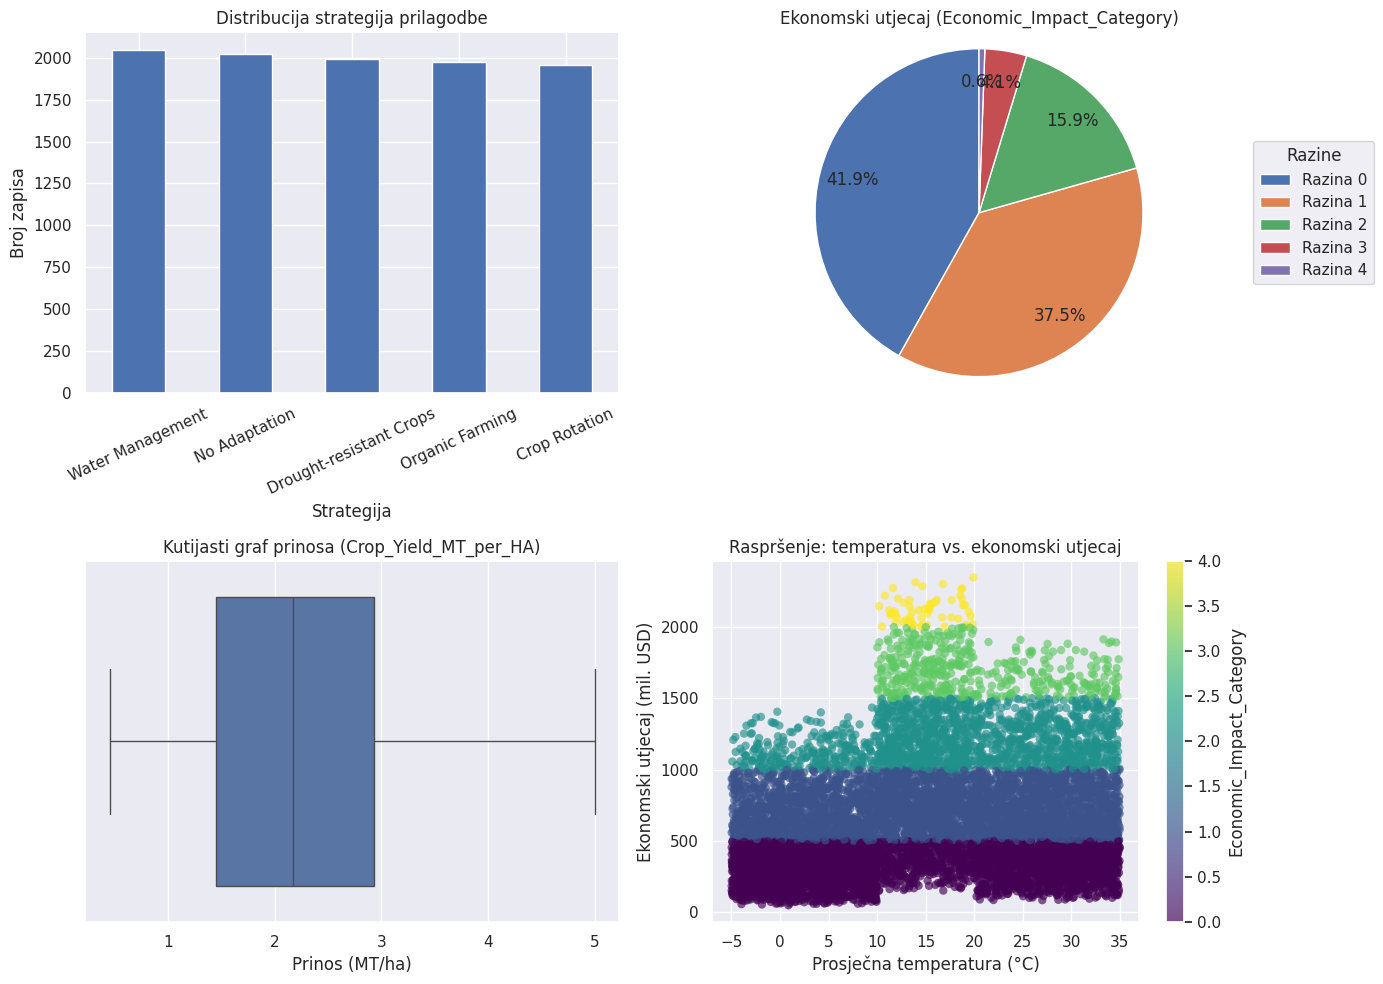

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="darkgrid", palette="deep")

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# stupčasti graf kategorijske varijable (Adaptation_Strategies)
ax1 = axes[0, 0]
df["Adaptation_Strategies"].value_counts().plot(kind="bar", ax=ax1)
ax1.set_title("Distribucija strategija prilagodbe")
ax1.set_xlabel("Strategija")
ax1.set_ylabel("Broj zapisa")
ax1.tick_params(axis="x", rotation=25)

# pie graf ciljane varijable
ax2 = axes[0, 1]
target_counts = df["Economic_Impact_Category"].value_counts().sort_index()

label_map = {
    0: "Razina 0",
    1: "Razina 1",
    2: "Razina 2",
    3: "Razina 3",
    4: "Razina 4"
}
labels = [label_map[i] for i in target_counts.index]

wedges, texts, autotexts = ax2.pie(
    target_counts,
    labels=None,
    autopct="%1.1f%%",
    startangle=90,
    pctdistance=0.8,
)
ax2.set_title("Ekonomski utjecaj (Economic_Impact_Category)")
ax2.axis("equal")

ax2.legend(wedges, labels, title="Razine", loc="center left", bbox_to_anchor=(1, 0.5))

# boxplot jedne numeričke varijable
ax3 = axes[1, 0]
sns.boxplot(x=df["Crop_Yield_MT_per_HA"], ax=ax3)
ax3.set_title("Kutijasti graf prinosa (Crop_Yield_MT_per_HA)")
ax3.set_xlabel("Prinos (MT/ha)")

# scatter dviju numeričkih, obojano po ciljnoj
ax4 = axes[1, 1]
sc = ax4.scatter(
    df["Average_Temperature_C"],
    df["Economic_Impact_Million_USD"],
    c=df["Economic_Impact_Category"],
    cmap="viridis",
    alpha=0.65,
    edgecolors="none"
)
ax4.set_title("Raspršenje: temperatura vs. ekonomski utjecaj")
ax4.set_xlabel("Prosječna temperatura (°C)")
ax4.set_ylabel("Ekonomski utjecaj (mil. USD)")

cbar = fig.colorbar(sc, ax=ax4)
cbar.set_label("Economic_Impact_Category")

plt.tight_layout()
plt.show()
